# Шаг 1. Подключаем библиотеки и первичные df

In [78]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import AutoMinorLocator
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from dotenv import load_dotenv
import os

## Создаем датафреймы из гугл таблиц

In [80]:
df_reg = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vT6rMyy3TfzrEheBOwlgts_SHTc67b_a8NsuSsfVnH6nI8x9zb9vt11gbMk1fWn4j3jvBxq9yqzPdhN/pub?gid=63066832&single=true&output=csv')

In [81]:
df_vis = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTC3r0B_geUBpk7soZCc03xDVzUBGMS__ZxPocgPQPmQ3guoVx9sXmNWwL2_vBHIFHVR_GDr4qlL5dH/pub?gid=1866591177&single=true&output=csv')

## Сводка общей информации по датафреймам

In [82]:
df_reg.describe()

,user_id
count,1.000000e+03
mean,4.488623e+06
std,2.620568e+06
min,2.236800e+04
25%,2.235489e+06
50%,4.473044e+06
75%,6.779707e+06
max,8.881772e+06


In [83]:
df_vis.describe()

,uuid,platform,user_agent,date
count,1000,1000,1000,1000
unique,519,3,28,996
top,251a0926-ece3-4d77-aa42-ab569fdf9fe2,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-03-01 8:01:45
freq,4,954,71,2


In [84]:
#просмотр текущих переменных. Удалить можно через del (имя)
%whos

Variable             Type         Data/Info
-------------------------------------------
API_URL              str          https://data-charts-api.hexlet.app
AutoMinorLocator     type         <class 'matplotlib.ticker.AutoMinorLocator'>
DATE_BEGIN           str          2023-09-01
DATE_END             str          2023-09-01
ads_period_grouped   DataFrame                             <...>   2023-08-06  2023-08-31
ax                   ndarray      2: 2 elems, type `object`, 16 bytes
charts               DataFrame         date_group platform <...>n\n[552 rows x 5 columns]
conv_by_platform     DataFrame    platform  date_group  and<...>n\n[184 rows x 4 columns]
daily_summary        DataFrame         date_group  total_vi<...>n\n[184 rows x 4 columns]
df_ads               DataFrame               date utm_sourc<...>n\n[159 rows x 5 columns]
df_ads_joined        DataFrame         date_group  visits  <...>n\n[552 rows x 5 columns]
df_api_regs          DataFrame                      datetim<...>

# Шаг 2. Подключение по API

In [85]:
load_dotenv()  # загружаются переменные из файла

DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')
API_URL = os.getenv('API_URL')

In [86]:
#r_visits = requests.get('https://data-charts-api.hexlet.app/visits?begin=2023-03-01&end=2023-09-01')
r_visits = requests.get(f'{API_URL}/visits?begin={DATE_BEGIN}&end={DATE_END}')

In [87]:
#r_regs = requests.get('https://data-charts-api.hexlet.app/registrations?begin=2023-03-01&end=2023-09-01')
r_regs = requests.get(f'{API_URL}/registrations?begin={DATE_BEGIN}&end={DATE_END}')

In [88]:
df_api_visits = pd.DataFrame(r_visits.json())
df_api_regs = pd.DataFrame(r_regs.json())

# Шаг 3. Расчет метрик

### Подготовка датафрейма визитов

Удаляем время из даты

In [89]:
df_api_visits['datetime'] = pd.to_datetime(df_api_visits['datetime'])
df_api_visits['datetime'] = df_api_visits['datetime'].dt.date

Удаляем ботов из датафрейма с регистрациями

In [90]:
mask = df_api_visits['platform'] == 'bot'
df_api_visits = df_api_visits[~mask]
df_api_visits.head()

,visit_id,platform,user_agent,datetime
0,59c69c6f-81b3-4e63-b1b3-00a950cf9feb,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-07-17
1,a82c5ae1-3d3b-485e-a483-df963c5e0e7a,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-07-21
2,a82c5ae1-3d3b-485e-a483-df963c5e0e7a,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-07-18
3,87525d18-3dce-4d81-8fa8-47d900c70a90,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-07-21
4,87525d18-3dce-4d81-8fa8-47d900c70a90,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-07-20


Оставляем последний визит каждого пользователя, если их было больше 1

In [91]:
df_api_visits.sort_values(by=['visit_id', 'datetime'], inplace=True)
df_api_visits.drop_duplicates(subset='visit_id', keep='last', inplace=True)

Группируем по дате и платформе

In [92]:
df_visits_grouped = df_api_visits[['datetime', 'platform']].groupby(['datetime', 'platform']).agg(visits = ('platform', 'count'))
df_visits_grouped.head()

visits
datetime   platform        
2023-03-01 android       75
           ios           22
           web          279
2023-03-02 android       67
           ios           31

### Подготовка датафрейма с регистрациями

In [93]:
df_api_regs['datetime'] = pd.to_datetime(df_api_regs['datetime'])
df_api_regs['datetime'] = df_api_regs['datetime'].dt.date

In [94]:
df_regs_grouped = df_api_regs[['datetime', 'platform']].groupby(['datetime', 'platform']).agg(registrations = ('platform', 'count'))
df_regs_grouped

registrations
datetime   platform               
2023-03-01 android              61
           ios                  18
           web                   8
2023-03-02 android              59
           ios                  24
...                            ...
2023-08-30 ios                  40
           web                  34
2023-08-31 android              42
           ios                  36
           web                  46

[552 rows x 1 columns]

### Объединение

In [95]:
df_joined = df_visits_grouped.join(df_regs_grouped, how = 'left')

In [96]:
df_joined = df_joined.rename_axis(index={'datetime': 'date_group'})

### Расчет конверсии

In [97]:
df_joined['conversion'] = (df_joined['registrations'] / df_joined['visits'] * 100.00).round(2)
df_joined.head()

visits  registrations  conversion
date_group platform                                   
2023-03-01 android       75             61       81.33
           ios           22             18       81.82
           web          279              8        2.87
2023-03-02 android       67             59       88.06
           ios           31             24       77.42

### Сохранение в json

In [98]:
df_joined.to_json('conversion.json', force_ascii=False)
print('Файл conversion.json успешно сохранен в корневом каталоге Colab. Вы можете скачать его, используя меню файлов слева.')

Файл conversion.json успешно сохранен в корневом каталоге Colab. Вы можете скачать его, используя меню файлов слева.


# Шаг 4. Добавляем рекламы

### Загрузка csv  с данными о рекламных кампаниях, подготовка данных

In [99]:
df_ads = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vT6RhvjENpQIKjGraRn24hPtM2REf8sYqvGh6pPCp3rwSfMagyiRSiUeZMugZWhimruBdoQzNeCAfEX/pub?gid=1700660919&single=true&output=csv')

In [100]:
df_ads['date'] = pd.to_datetime(df_ads['date'])
df_ads['date'] = df_ads['date'].dt.date
df_ads.head()

,date,utm_source,utm_medium,utm_campaign,cost
0,2023-03-01,google,cpc,advanced_algorithms_series,212
1,2023-03-02,google,cpc,advanced_algorithms_series,252
2,2023-03-03,google,cpc,advanced_algorithms_series,202
3,2023-03-04,google,cpc,advanced_algorithms_series,223
4,2023-03-05,google,cpc,advanced_algorithms_series,265


In [101]:
df_joined.reset_index(inplace=True)
df_joined

,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.33
1,2023-03-01,ios,22,18,81.82
2,2023-03-01,web,279,8,2.87
3,2023-03-02,android,67,59,88.06
4,2023-03-02,ios,31,24,77.42
...,...,...,...,...,...
547,2023-08-30,ios,66,40,60.61
548,2023-08-30,web,1227,34,2.77
549,2023-08-31,android,57,42,73.68
550,2023-08-31,ios,50,36,72.00


### Объединяем конверсии и рекламы

In [102]:
df_ads_joined = pd.merge(df_joined, df_ads, left_on='date_group', right_on='date', how='left')

In [103]:
#Оставляем поля, указанные в требованиях шага 4
df_ads_joined = df_ads_joined[['date_group', 'visits','registrations','cost', 'utm_campaign']]
df_ads_joined

,date_group,visits,registrations,cost,utm_campaign
0,2023-03-01,75,61,212.0,advanced_algorithms_series
1,2023-03-01,22,18,212.0,advanced_algorithms_series
2,2023-03-01,279,8,212.0,advanced_algorithms_series
3,2023-03-02,67,59,252.0,advanced_algorithms_series
4,2023-03-02,31,24,252.0,advanced_algorithms_series
...,...,...,...,...,...
547,2023-08-30,66,40,109.0,intro_to_python_course
548,2023-08-30,1227,34,109.0,intro_to_python_course
549,2023-08-31,57,42,215.0,intro_to_python_course
550,2023-08-31,50,36,215.0,intro_to_python_course


### Сохраняем в json

In [104]:
#Объединенный файл реклам и конверсий
df_ads_joined.to_json('ads.json')

In [105]:
#Изначально загруженный файл с рекламами
df_ads.to_csv('ads.csv')

# Шаг 5. Визуализации

In [106]:
#Для визуализаций будем использовать charts
charts = df_joined
charts['date_group'] = pd.to_datetime(charts['date_group']).dt.date

### Итоговые визиты

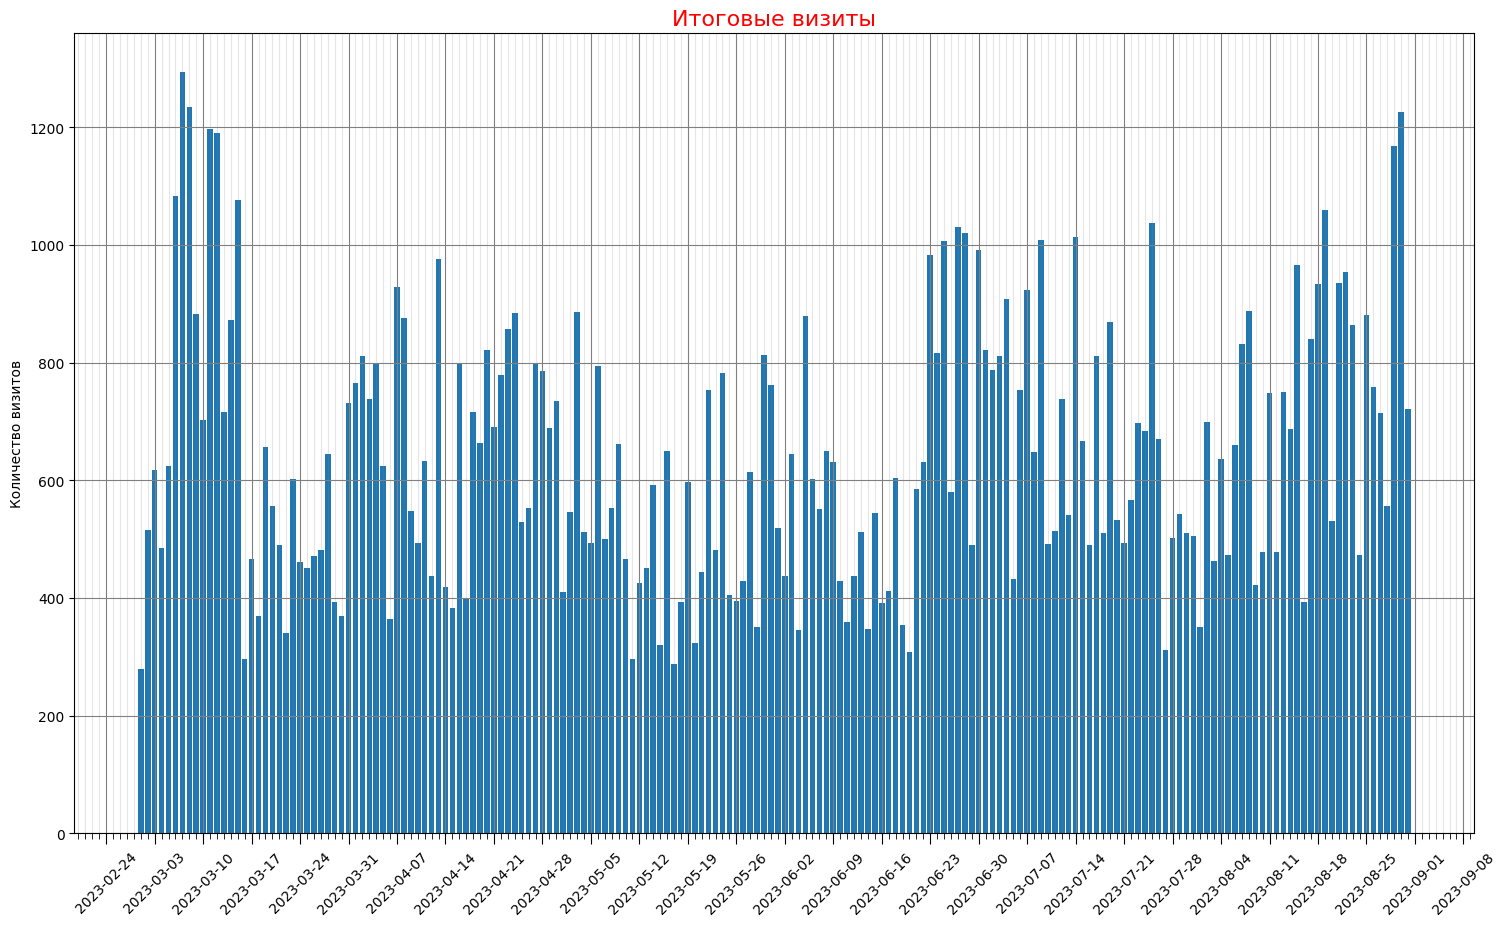

In [115]:
fig = plt.figure(figsize=(14,8))
ax = plt.axes([0,0,1,1])
ax.bar(charts['date_group'], charts['visits'])
ax.set_title('Итоговые визиты', fontsize=16, color='red')
ax.set_ylabel('Количество визитов', fontsize=10)
#ax.set_xlim(pd.to_datetime('2023-02-28'), pd.to_datetime('2023-09-01'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="gray")
ax.grid(which="minor", color="gray")

plt.savefig('./charts/total_visits.png')
plt.show()

### Итоговые визиты в разрезе платформ (web, Android, ios)

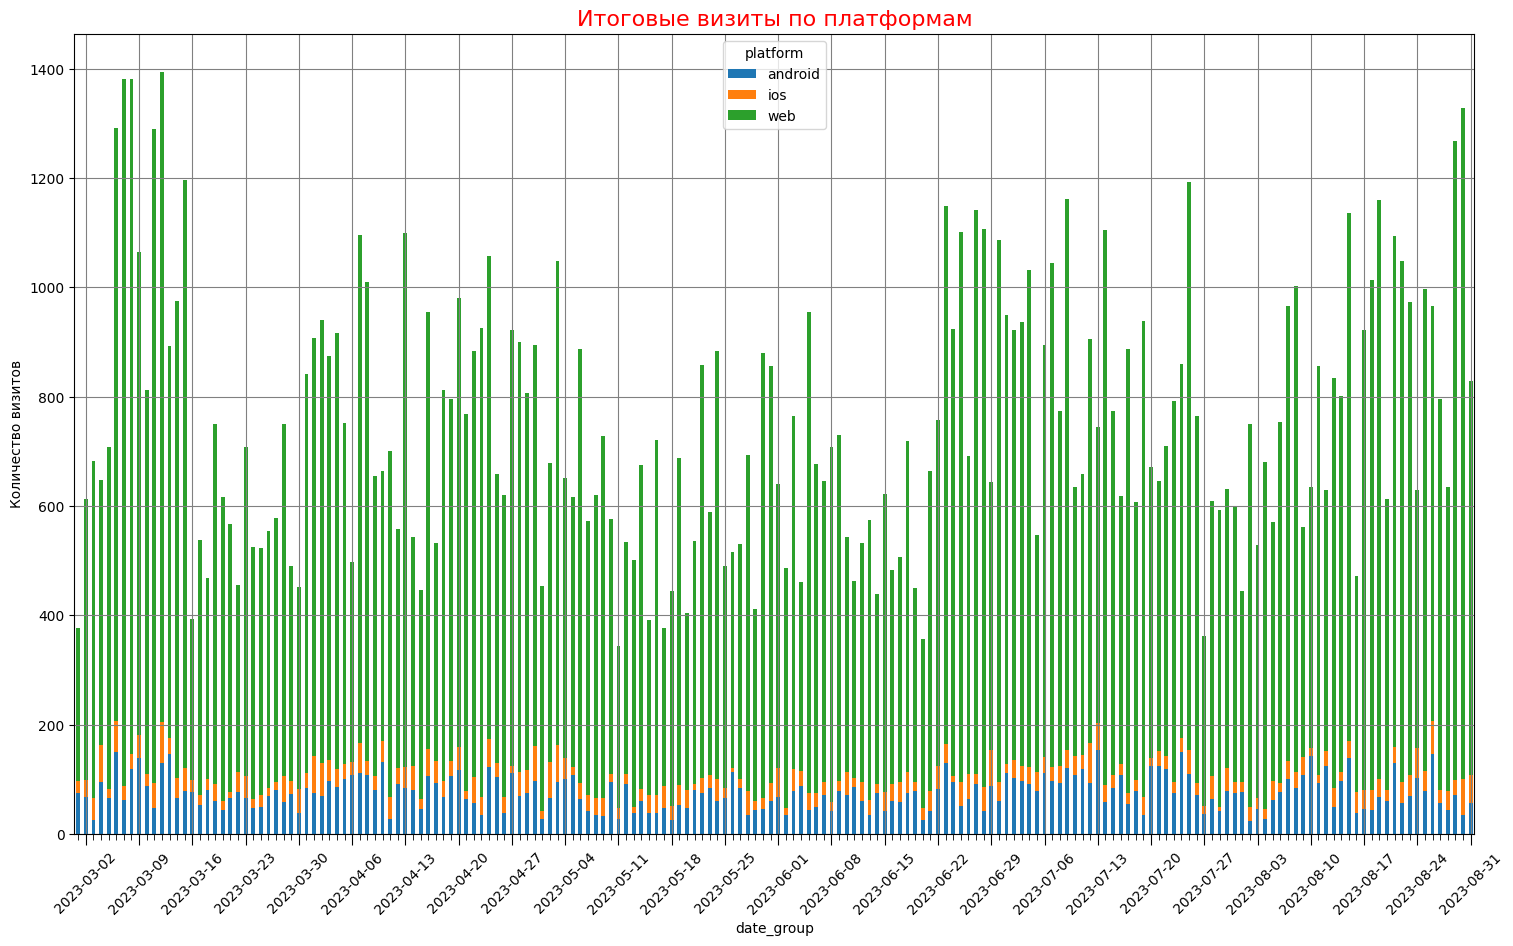

In [108]:
vis_by_platform = charts.pivot_table(index='date_group', columns='platform', values='visits')

fig = plt.figure(figsize=(14,8))
ax = plt.axes([0,0,1,1])
vis_by_platform.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Итоговые визиты по платформам', fontsize=16, color='red')
ax.set_ylabel('Количество визитов', fontsize=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.grid(which="major", color="gray")

plt.savefig('./charts/total_visit_by_platform.png')
plt.show()

### Итоговые регистрации

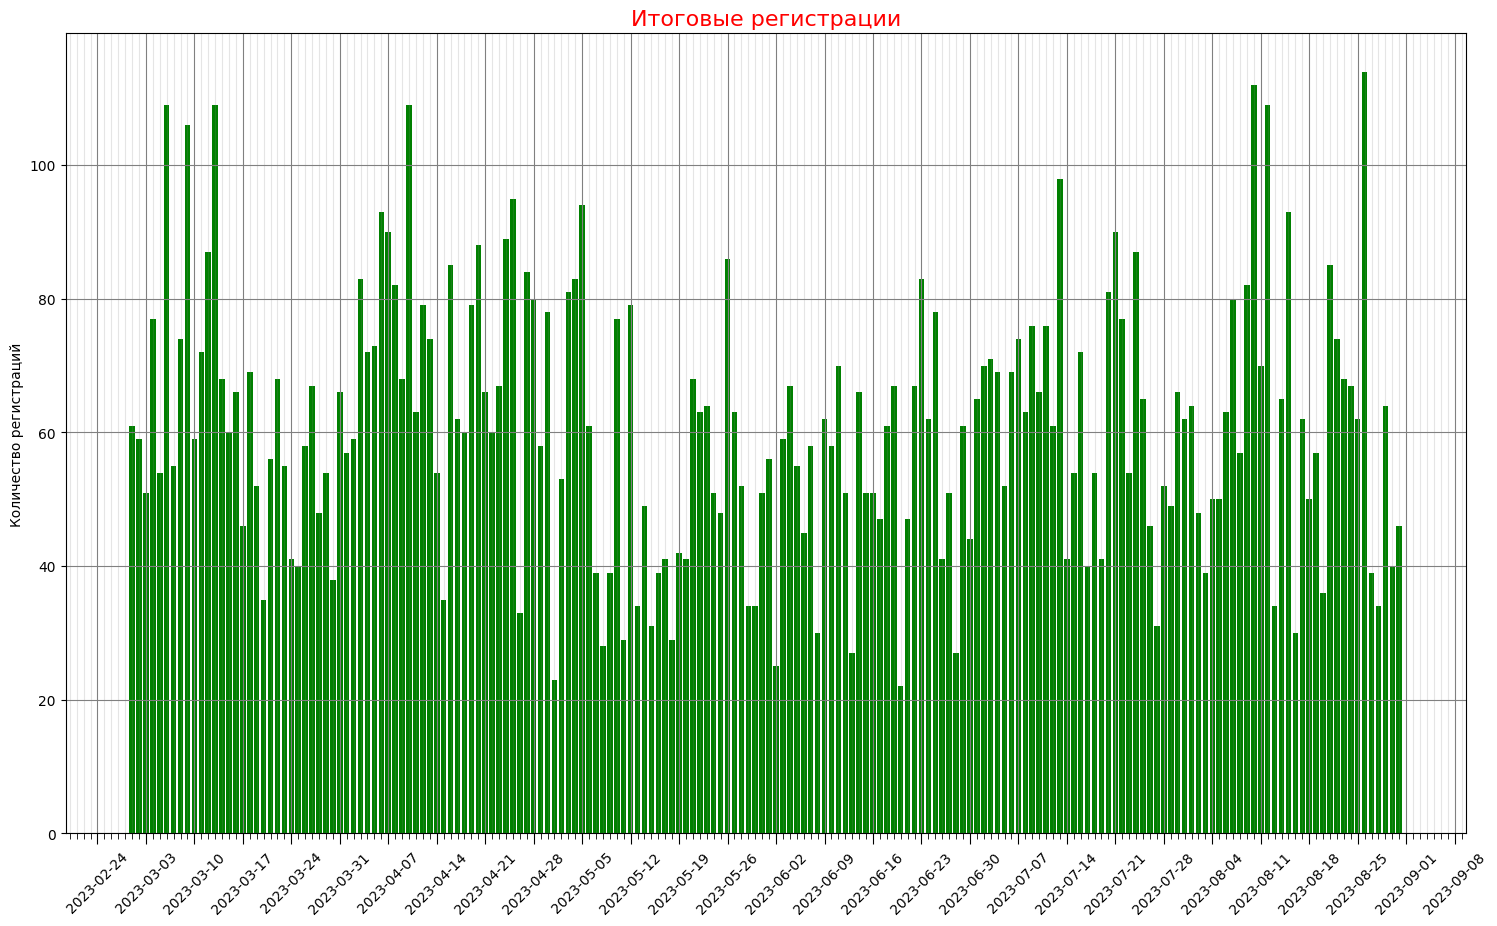

In [109]:
fig = plt.figure(figsize=(14,8))
ax = plt.axes([0,0,1,1])
ax.bar(charts['date_group'], charts['registrations'], color='g')
ax.set_title('Итоговые регистрации', fontsize=16, color='red')
ax.set_ylabel('Количество регистраций', fontsize=10)
#ax.set_xlim(pd.to_datetime('2023-02-28'), pd.to_datetime('2023-09-01'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="gray")
ax.grid(which="minor", color="gray")

plt.savefig('./charts/total_registrations.png')
plt.show()

### Итоговые регистрации с разбивкой по платформам

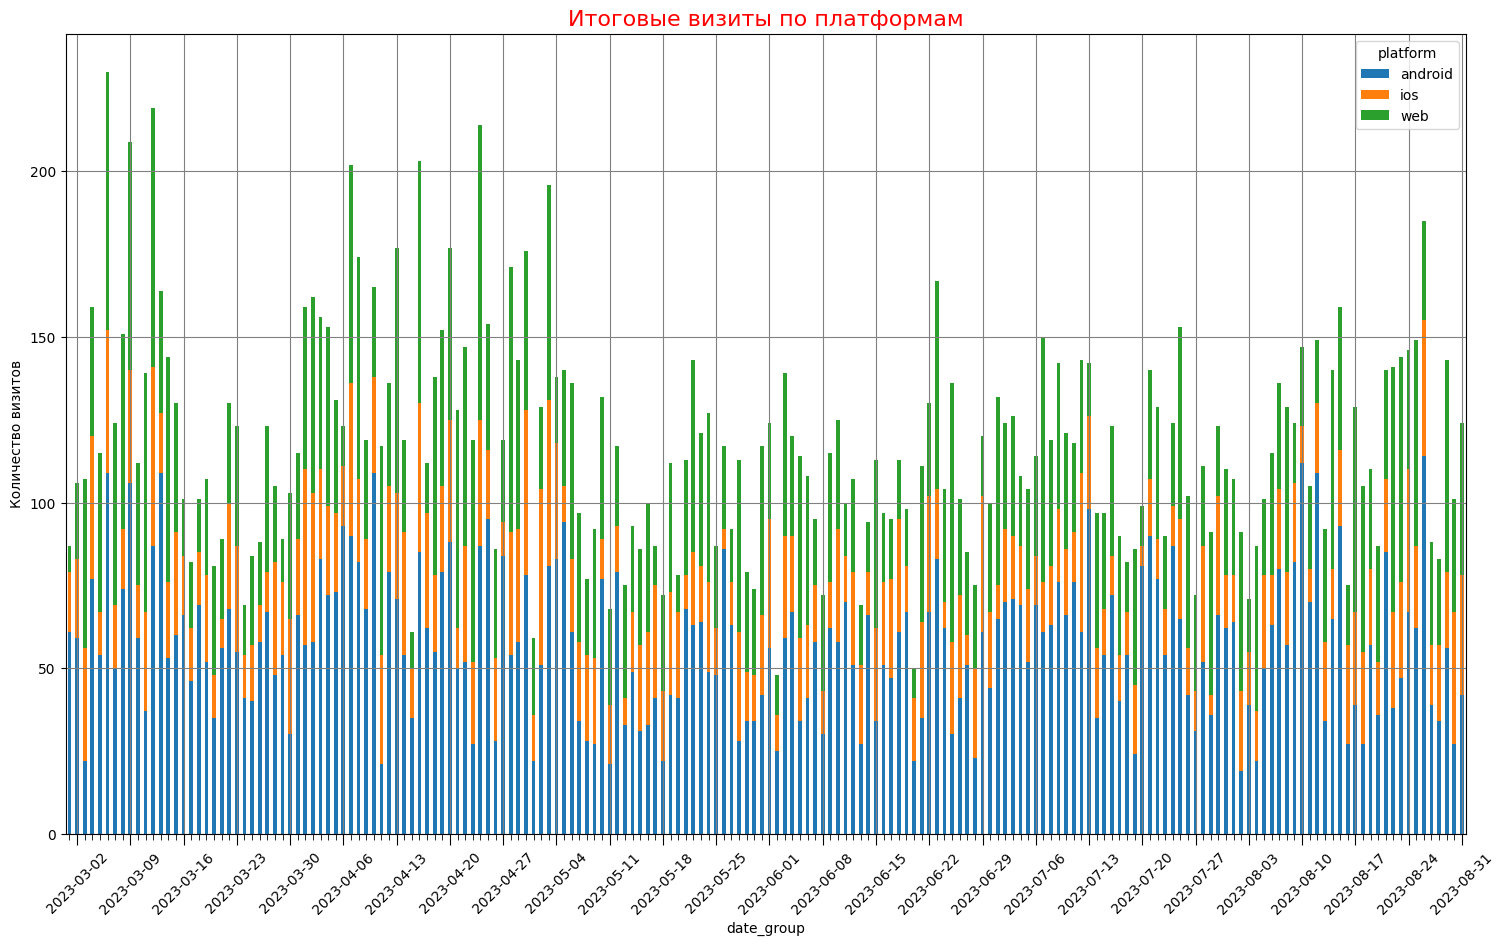

In [110]:
regs_by_platform = charts.pivot_table(index='date_group', columns='platform', values='registrations')

fig = plt.figure(figsize=(14,8))
ax = plt.axes([0,0,1,1])
regs_by_platform.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Итоговые визиты по платформам', fontsize=16, color='red')
ax.set_ylabel('Количество визитов', fontsize=10)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.grid(which="major", color="gray")

plt.savefig('./charts/total_registrations_by_platform.png')
plt.show()

### Итоговые конверсии

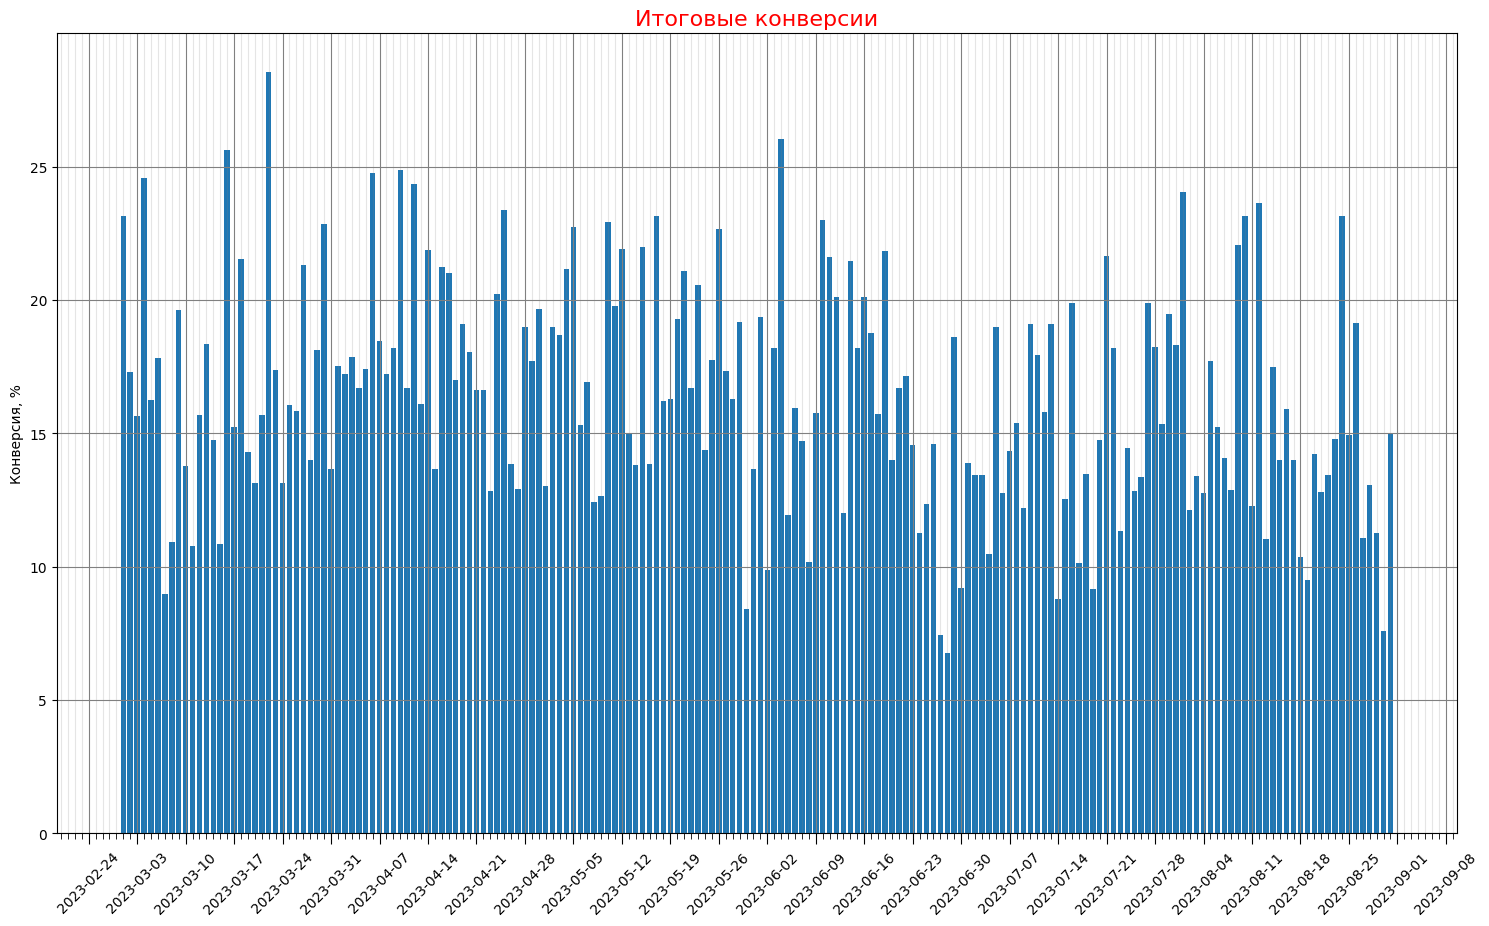

In [111]:
#Находим суммарные визиты и регистрации без разбивки по платформам
daily_summary = charts.groupby('date_group').agg(
    total_visits=('visits', 'sum'),
    total_registrations=('registrations', 'sum')
).reset_index()

#Добавляем конверсию без разбивки по платформам
daily_summary['conversion'] = (daily_summary['total_registrations'] / daily_summary['total_visits'] * 100.00).round(2)

fig = plt.figure(figsize=(14,8))
ax = plt.axes([0,0,1,1])
ax.bar(daily_summary['date_group'], daily_summary['conversion'])
ax.set_title('Итоговые конверсии', fontsize=16, color='red')
ax.set_ylabel('Конверсия, %', fontsize=10)
#ax.set_xlim(pd.to_datetime('2023-02-28'), pd.to_datetime('2023-09-01'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="gray")
ax.grid(which="minor", color="gray")

plt.savefig('./charts/conversions.png')
plt.show()

### Конверсия по платформам

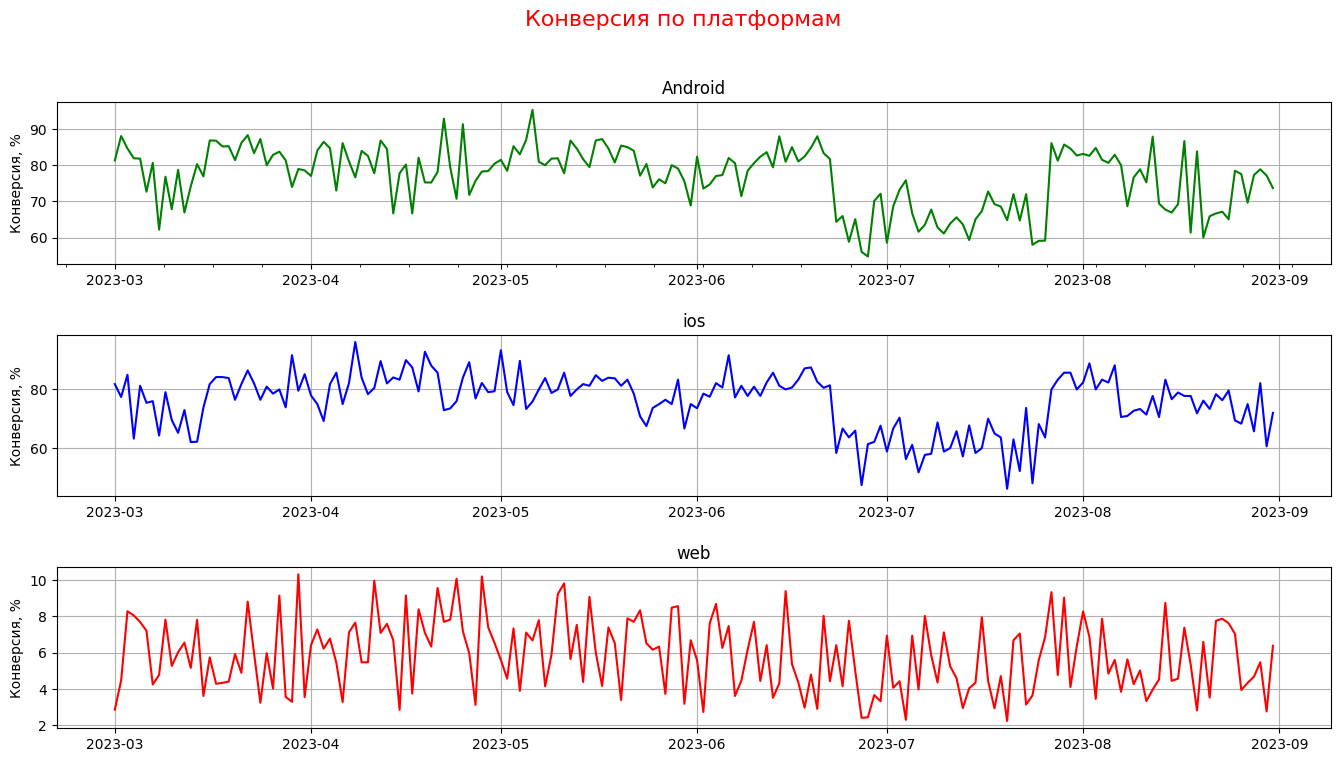

In [112]:
conv_by_platform = charts.pivot_table(index='date_group', columns='platform', values='conversion').reset_index()

fig, ax = plt.subplots(3, 1, figsize=(14,8))
fig.suptitle('Конверсия по платформам', fontsize=16, color='red')
plt.tight_layout(pad=3.0)

ax[0].plot(conv_by_platform['date_group'], conv_by_platform['android'], color='green')
ax[0].set_title('Android')
ax[0].xaxis.set_minor_locator(AutoMinorLocator(4))
ax[0].set_ylabel('Конверсия, %')
ax[0].grid()

ax[1].plot(conv_by_platform['date_group'], conv_by_platform['ios'], color='blue')
ax[1].set_title('ios')
ax[0].xaxis.set_minor_locator(AutoMinorLocator(4))
ax[1].set_ylabel('Конверсия, %')
ax[1].grid()


ax[2].plot(conv_by_platform['date_group'], conv_by_platform['web'], color='red')
ax[2].set_title('web')
ax[0].xaxis.set_minor_locator(AutoMinorLocator(4))
ax[2].set_ylabel('Конверсия, %')
ax[2].grid()

plt.savefig('./charts/conversion_by_platform.png')
plt.show()

### Стоимости реклам

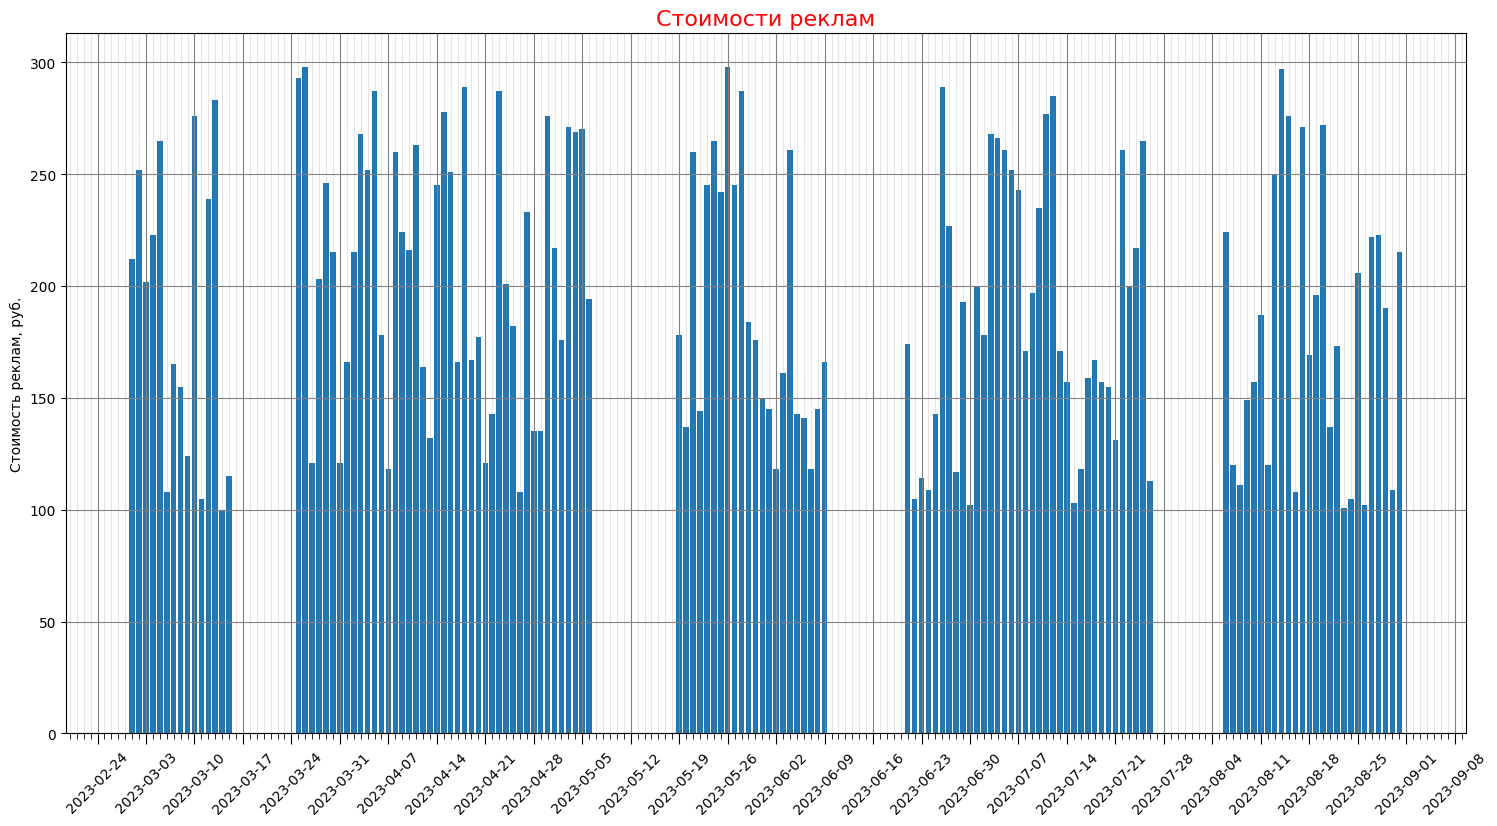

In [113]:
fig = plt.figure(figsize=(14,7))
ax = plt.axes([0,0,1,1])
ax.bar(df_ads_joined['date_group'], df_ads_joined['cost'])
ax.set_title('Стоимости реклам', fontsize=16, color='red')
ax.set_ylabel('Стоимость реклам, руб.', fontsize=10)
#ax.set_xlim(pd.to_datetime('2023-02-28'), pd.to_datetime('2023-09-01'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_minor_locator(AutoMinorLocator(7))
ax.tick_params(which='major', axis='x', length=8, labelrotation=45)
ax.tick_params(which='minor', axis='x', labelsize=7, length=4, grid_alpha=0.2, labelrotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(which="major", color="gray")
ax.grid(which="minor", color="gray")

plt.savefig('./charts/ads_cost.png')
plt.show()

### Визиты и регистрации с выделением рекламных кампаний

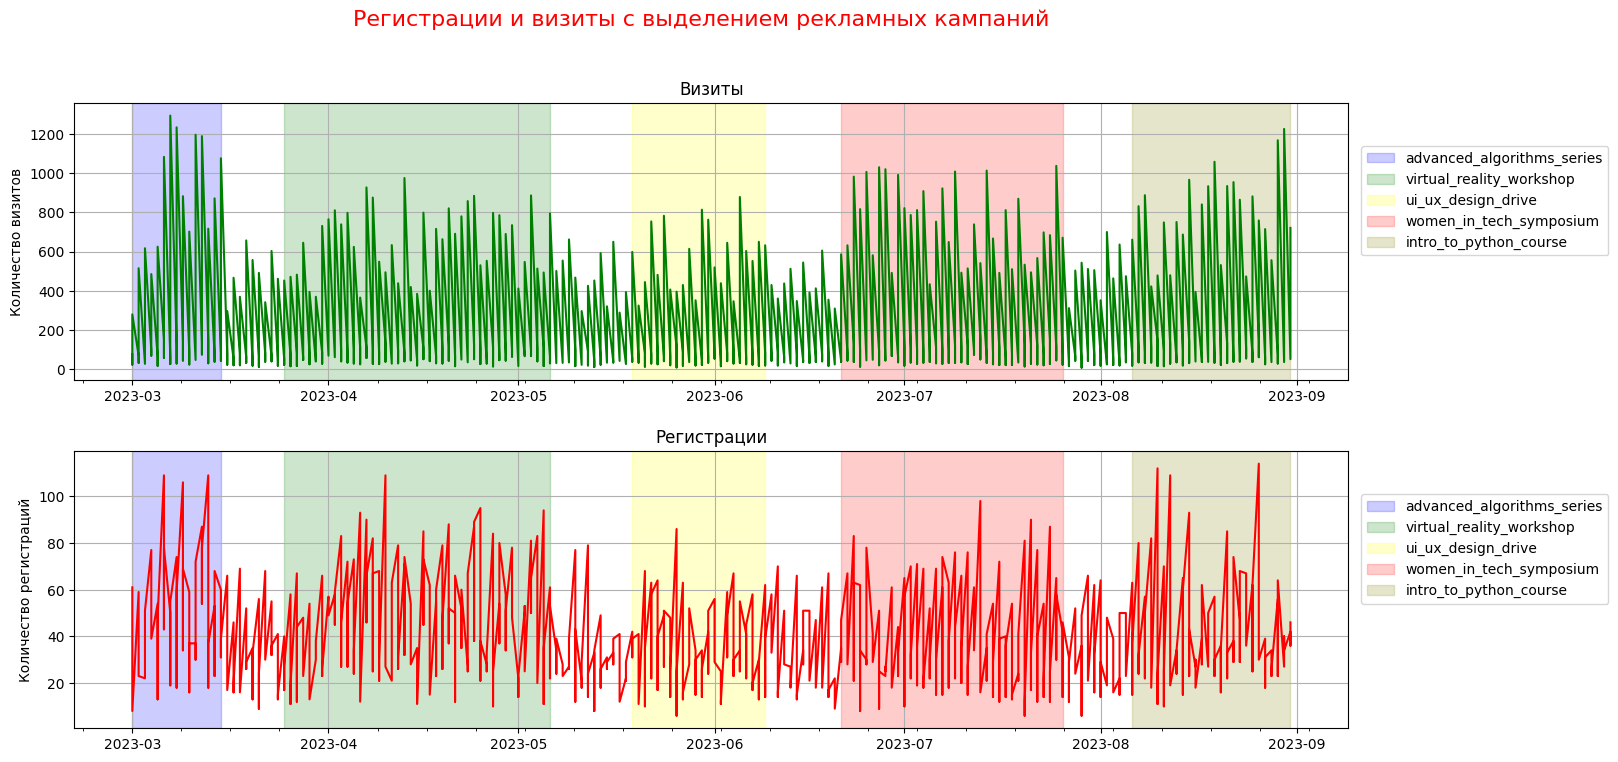

In [114]:
#Определяем даты старта (min) и окончания (max) для каждой рекламной кампании
ads_period_grouped = df_ads_joined[['date_group', 'utm_campaign']].groupby('utm_campaign').agg(min=('date_group', 'min'), max=('date_group', 'max')).sort_values(by='min')

fig, ax = plt.subplots(2, 1, figsize=(14,8))
fig.suptitle('Регистрации и визиты с выделением рекламных кампаний', fontsize=16, color='red')
plt.tight_layout(pad=3.0)

ax[0].plot(charts['date_group'], charts['visits'], color='green')
ax[0].axvspan(ads_period_grouped.iloc[0,0], ads_period_grouped.iloc[0,1], alpha=0.2, label = ads_period_grouped.index[0], color='blue')
ax[0].axvspan(ads_period_grouped.iloc[1,0], ads_period_grouped.iloc[1,1], alpha=0.2, label = ads_period_grouped.index[1], color='green')
ax[0].axvspan(ads_period_grouped.iloc[2,0], ads_period_grouped.iloc[2,1], alpha=0.2, label = ads_period_grouped.index[2], color='yellow')
ax[0].axvspan(ads_period_grouped.iloc[3,0], ads_period_grouped.iloc[3,1], alpha=0.2, label = ads_period_grouped.index[3], color='red')
ax[0].axvspan(ads_period_grouped.iloc[4,0], ads_period_grouped.iloc[4,1], alpha=0.2, label = ads_period_grouped.index[4], color='olive')
ax[0].set_title('Визиты')
ax[0].xaxis.set_minor_locator(AutoMinorLocator(4))
ax[0].set_ylabel('Количество визитов')
ax[0].legend(loc=(1.01, 0.45))
ax[0].grid()

ax[1].plot(charts['date_group'], charts['registrations'], color='red')
ax[1].axvspan(ads_period_grouped.iloc[0,0], ads_period_grouped.iloc[0,1], alpha=0.2, label = ads_period_grouped.index[0], color='blue')
ax[1].axvspan(ads_period_grouped.iloc[1,0], ads_period_grouped.iloc[1,1], alpha=0.2, label = ads_period_grouped.index[1], color='green')
ax[1].axvspan(ads_period_grouped.iloc[2,0], ads_period_grouped.iloc[2,1], alpha=0.2, label = ads_period_grouped.index[2], color='yellow')
ax[1].axvspan(ads_period_grouped.iloc[3,0], ads_period_grouped.iloc[3,1], alpha=0.2, label = ads_period_grouped.index[3], color='red')
ax[1].axvspan(ads_period_grouped.iloc[4,0], ads_period_grouped.iloc[4,1], alpha=0.2, label = ads_period_grouped.index[4], color='olive')
ax[1].set_title('Регистрации')
ax[1].xaxis.set_minor_locator(AutoMinorLocator(4))
ax[1].set_ylabel('Количество регистраций')
ax[1].legend(loc=(1.01, 0.45))
ax[1].grid()

plt.savefig('./charts/visits_regs_with_ads.png')
plt.show()